# Experiments Master Notebook

Unified notebook covering **E1–E9** from `experiment_checklist.md`.

**Workflow:**
1. Run `python implementation/generate_data.py` first (populates `results/data_cache.h5`).
2. Re-run this notebook — it loads from the cache and produces all paper figures.
3. If the cache is missing, it falls back to a single-seed run (slower, no error bars).


## Setup

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

warnings.filterwarnings('ignore', category=RuntimeWarning)

# ── locate repo root ──────────────────────────────────────────────────────
def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / 'QP_simulator').exists() and (p / 'implementation').exists():
            return p
    raise RuntimeError(f'Cannot locate repo root from {start}')

REPO = find_repo_root()
for _p in [REPO, REPO/'src', REPO/'QP_simulator', REPO/'implementation']:
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

CACHE_H5 = REPO / 'results' / 'data_cache.h5'
FIG_DIR   = REPO / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', REPO)
print('Cache h5 :', CACHE_H5, '— exists:', CACHE_H5.exists())


Repo root: /ceph/dwong/noise-weighted-subspace-reconstruction
Cache h5 : /ceph/dwong/noise-weighted-subspace-reconstruction/results/data_cache.h5 — exists: True


In [2]:
# ── matplotlib style ─────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'lines.linewidth': 1.6,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
BLUE, ORANGE, GREEN, RED = '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print(f'  saved → {path.relative_to(REPO)}')

# ── h5 loaders ───────────────────────────────────────────────────────────
def load_df(h5, path):
    grp = h5[path]
    d = {}
    for k in grp.keys():
        v = grp[k][()]
        if v.dtype.kind == 'S':
            v = np.array([x.decode() for x in v])
        d[k] = v
    return pd.DataFrame(d)

def load_attr(h5, path, attr):
    return h5[path].attrs[attr]

def cache_groups(h5, prefix):
    """Return list of seed groups under prefix."""
    if prefix not in h5:
        return []
    return sorted(h5[prefix].keys())

print('Setup done.')


Setup done.


## Fallback: single-seed inline run

Only executes when `data_cache.h5` does not exist. 
Generates data for one seed so every plot below has *something* to display.


In [3]:
if not CACHE_H5.exists():
    print('Cache not found — running single-seed fallback (this may take a few minutes)...')
    from notebook_support import (
        CanonicalConfig,
        run_block04_theorem_suite, run_block05_bridge_suite,
        run_block06_convergence_suite, run_block07_ablation_suite,
    )
    _cfg = CanonicalConfig(seed=314159, sim_events_medium=200, sim_events_large=200).validate()
    _fallback = {
        'b04': run_block04_theorem_suite(_cfg),
        'b05': run_block05_bridge_suite(_cfg),
        'b06': run_block06_convergence_suite(_cfg),
        'b07': run_block07_ablation_suite(_cfg),
    }
    print('Fallback done.')
else:
    _fallback = None
    print('Cache found — using h5.')


Cache found — using h5.


In [4]:
def agg_seeds(h5, prefix, subgroup, col):
    """Collect `col` from all seed sub-groups and return stacked array."""
    rows = []
    for sg in cache_groups(h5, prefix):
        path = f'{prefix}/{sg}/{subgroup}'
        if path not in h5:
            continue
        v = h5[path][col][()]
        if v.dtype.kind == 'S':
            v = np.array([x.decode() for x in v])
        rows.append(v)
    if not rows:
        return None
    return np.stack(rows, axis=0)   # (n_seeds, n_points)

def mean_std(arr):
    """Axis-0 mean and std. Returns (mean, std) both shape (n_points,)."""
    return arr.mean(0), arr.std(0, ddof=1) if arr.shape[0] > 1 else (arr.mean(0), np.zeros(arr.shape[1:]))

print('Aggregation helpers ready.')


Aggregation helpers ready.


---
## E1 — Theorem 1: rank-1 EMPCA ≡ Optimal Filter

*Paper §4.3, Table 1 in §3.  
Pass criteria: ρ_w > 0.9999, amp correlation > 0.999, median rel error < 1e-3, KS p > 0.05.*


In [5]:
e1_rows = []
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e1_e4_e5'):
        path = f'e1_e4_e5/{sg}/e1'
        if path not in h5:
            continue
        df = load_df(h5, path)
        df['seed'] = sg
        e1_rows.append(df)

if e1_rows:
    e1_all = pd.concat(e1_rows, ignore_index=True)
elif _fallback:
    e1_all = _fallback['b04']['rank1_summary_df'].copy()
    e1_all['seed'] = 'fallback'
else:
    raise RuntimeError('No E1 data')

print('E1 results across seeds:')
display(e1_all)

# pass/fail
thresholds = {
    'weighted_subspace_cosine': (0.9999, '>='),
    'amplitude_correlation':    (0.999,  '>='),
    'median_relative_error':    (1e-3,   '<='),
    'residual_ks_pvalue':       (0.05,   '>='),
}
numeric_cols = [c for c in thresholds if c in e1_all.columns]
summary = e1_all[numeric_cols].agg(['mean', 'std']).T
summary.columns = ['mean', 'std']
for col, (thresh, op) in thresholds.items():
    if col not in summary.index:
        continue
    mu = summary.loc[col, 'mean']
    passed = (mu >= thresh) if op == '>=' else (mu <= thresh)
    summary.loc[col, 'threshold'] = thresh
    summary.loc[col, 'pass'] = '✓' if passed else '✗'
print('\nE1 pass/fail summary:')
display(summary)


E1 results across seeds:


,amplitude_correlation,median_relative_error,residual_ks_pvalue,weighted_subspace_cosine,seed
0,0.999999,0.001858,1.0,0.999065,seed_100003
1,0.999999,0.001978,1.0,0.999014,seed_141421
2,0.999999,0.001940,1.0,0.999034,seed_161803
3,0.999999,0.001985,1.0,0.999032,seed_200003
4,0.999999,0.001978,1.0,0.999004,seed_271828
5,0.999999,0.001987,1.0,0.999007,seed_300007
6,0.999999,0.001907,1.0,0.999051,seed_314159
7,0.999999,0.001884,1.0,0.999041,seed_400009



E1 pass/fail summary:


,mean,std,threshold,pass
weighted_subspace_cosine,0.999031,2.169980e-05,0.9999,✗
amplitude_correlation,0.999999,1.774327e-07,0.9990,✓
median_relative_error,0.001940,5.085170e-05,0.0010,✗
residual_ks_pvalue,1.000000,1.034172e-07,0.0500,✓


---
## E2 — Theorem 2: noise-aware linear AE ≡ EMPCA

*Paper §5.3.  
Pass criterion: minimum principal-angle cosine > 0.9999 for k = 1, 2, 3.*


  saved → results/figures/e2_bridge_cosines.pdf


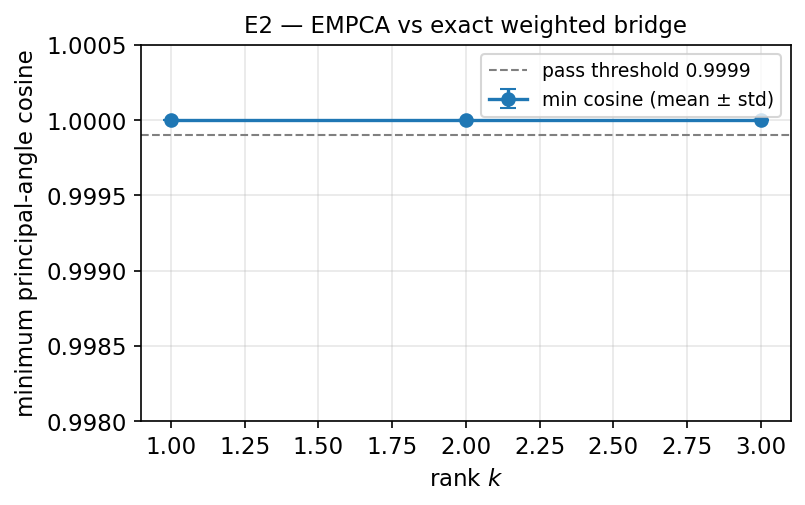


E2 pass (all k ≥ 0.9999): True


In [6]:
e2_by_k = {}   # k -> list of min_cosine values across seeds
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e2'):
        path = f'e2/{sg}'
        if path not in h5:
            continue
        df = load_df(h5, path)
        if 'k' not in df.columns or 'min_principal_cosine' not in df.columns:
            continue
        for _, row in df.iterrows():
            k = int(row['k'])
            e2_by_k.setdefault(k, []).append(float(row['min_principal_cosine']))

if not e2_by_k and _fallback:
    bd = _fallback['b05']['bridge_df'].copy()
    bd['min_principal_cosine'] = bd['principal_angle_cosines'].map(
        lambda x: min(x) if hasattr(x, '__iter__') else x)
    for _, row in bd.iterrows():
        e2_by_k.setdefault(int(row['k']), []).append(float(row['min_principal_cosine']))

ks = sorted(e2_by_k.keys())
mu_e2 = np.array([np.mean(e2_by_k[k]) for k in ks])
sd_e2 = np.array([np.std(e2_by_k[k], ddof=1) if len(e2_by_k[k]) > 1 else 0.0 for k in ks])

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.errorbar(ks, mu_e2, yerr=sd_e2, fmt='o-', color=BLUE, capsize=4, label='min cosine (mean ± std)')
ax.axhline(0.9999, color='gray', ls='--', lw=1, label='pass threshold 0.9999')
ax.set_xlabel('rank $k$')
ax.set_ylabel('minimum principal-angle cosine')
ax.set_title('E2 — EMPCA vs exact weighted bridge')
ax.set_ylim(0.998, 1.0005)
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'e2_bridge_cosines.pdf')
plt.show()

print(f'\nE2 pass (all k ≥ 0.9999): {all(m >= 0.9999 for m in mu_e2)}')


---
## E4 — Cramér-Rao Bound verification

*Paper §3.2.  
Pass: |σ²_emp − 1/N_Φ| / (1/N_Φ) < 5% for each noise colour.*


,noise_type,mean_rel_error,std_rel_error,pass
0,brownian,0.018183,0.014935,✓
1,pink,0.030431,0.015968,✓
2,white,0.035439,0.013358,✓


  saved → results/figures/e4_crb_verification.pdf


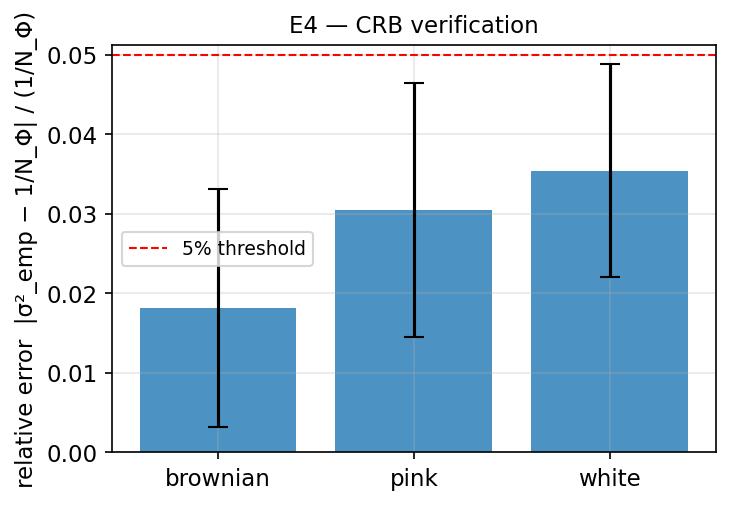

In [7]:
e4_rows = []
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e1_e4_e5'):
        path = f'e1_e4_e5/{sg}/e4'
        if path not in h5:
            continue
        df = load_df(h5, path)
        df['seed'] = sg
        e4_rows.append(df)

if e4_rows:
    e4_all = pd.concat(e4_rows, ignore_index=True)
elif _fallback:
    e4_all = _fallback['b04']['crb_df'].copy()
    e4_all['seed'] = 'fallback'
else:
    raise RuntimeError('No E4 data')

# aggregate relative_error across seeds per noise_type
e4_agg = e4_all.groupby('noise_type')['relative_error'].agg(['mean', 'std']).reset_index()
e4_agg.columns = ['noise_type', 'mean_rel_error', 'std_rel_error']
e4_agg['pass'] = e4_agg['mean_rel_error'].apply(lambda x: '✓' if x < 0.05 else '✗')

display(e4_agg)

fig, ax = plt.subplots(figsize=(5, 3.5))
x = np.arange(len(e4_agg))
bars = ax.bar(x, e4_agg['mean_rel_error'], yerr=e4_agg['std_rel_error'].fillna(0),
              capsize=5, color=BLUE, alpha=0.8, error_kw={'ecolor': 'black', 'lw': 1.5})
ax.axhline(0.05, color='red', ls='--', lw=1, label='5% threshold')
ax.set_xticks(x)
ax.set_xticklabels(e4_agg['noise_type'])
ax.set_ylabel('relative error  |σ²_emp − 1/N_Φ| / (1/N_Φ)')
ax.set_title('E4 — CRB verification')
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'e4_crb_verification.pdf')
plt.show()


---
## E5 — Energy resolution: σ_E ∝ noise_power^{1/2}

*Paper §3.2.  
The log-log slope of σ_emp vs noise_power should be 0.5.  
Error bars show std across seeds.*


  saved → results/figures/e5_resolution_scaling.pdf


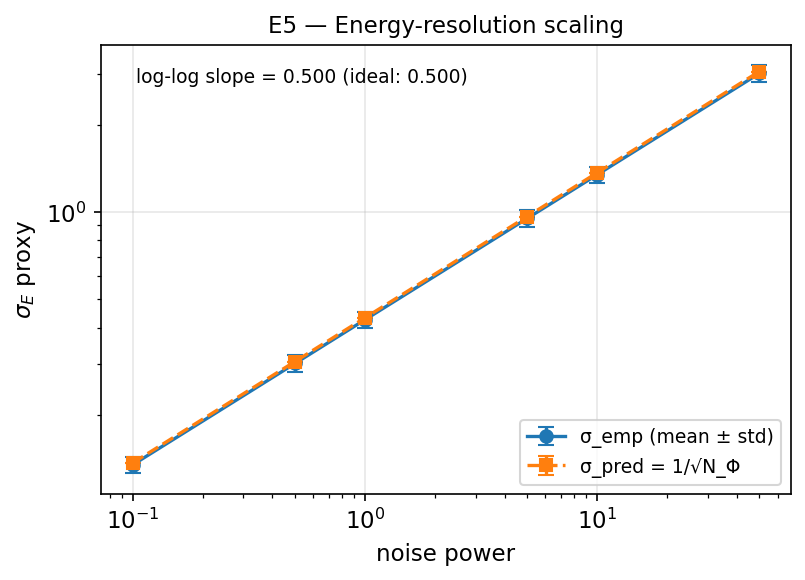

log-log slope: 0.5000 ± 0.0000
Pass (slope ≈ 0.5, |err| < 0.05): True


In [8]:
# Collect resolution curves from all seeds
e5_power_lists = {}
e5_sigma_emp_lists = {}
e5_sigma_pred_lists = {}

with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e1_e4_e5'):
        path = f'e1_e4_e5/{sg}/e5'
        if path not in h5:
            continue
        df = load_df(h5, path)
        np_arr = df['noise_power'].values.astype(float)
        e5_power_lists[sg] = np_arr
        e5_sigma_emp_lists[sg] = df['sigma_emp'].values.astype(float)
        e5_sigma_pred_lists[sg] = df['sigma_pred'].values.astype(float)

if not e5_power_lists and _fallback:
    df = _fallback['b04']['resolution_df']
    e5_power_lists['fallback']     = df['noise_power'].values.astype(float)
    e5_sigma_emp_lists['fallback'] = df['sigma_emp'].values.astype(float)
    e5_sigma_pred_lists['fallback']= df['sigma_pred'].values.astype(float)

# Stack seeds (assumes all seeds use same noise_power grid)
powers = list(e5_power_lists.values())[0]
sigma_emp_stack = np.stack(list(e5_sigma_emp_lists.values()), axis=0)   # (seeds, powers)
sigma_pred_stack= np.stack(list(e5_sigma_pred_lists.values()), axis=0)
mu_emp, sd_emp   = mean_std(sigma_emp_stack)
mu_pred, sd_pred = mean_std(sigma_pred_stack)

# log-log slope
slopes = [np.polyfit(np.log(p), np.log(s), 1)[0]
          for p, s in zip(e5_power_lists.values(), e5_sigma_emp_lists.values())]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.errorbar(powers, mu_emp, yerr=sd_emp, fmt='o-', color=BLUE,
            capsize=4, label='σ_emp (mean ± std)')
ax.errorbar(powers, mu_pred, yerr=sd_pred, fmt='s--', color=ORANGE,
            capsize=4, label='σ_pred = 1/√N_Φ')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('noise power')
ax.set_ylabel(r'$\sigma_E$ proxy')
ax.set_title('E5 — Energy-resolution scaling')
ax.legend(fontsize=9)
slope_mu = np.mean(slopes)
ax.text(0.05, 0.95, f'log-log slope = {slope_mu:.3f} (ideal: 0.500)',
        transform=ax.transAxes, va='top', fontsize=9)
fig.tight_layout()
save_fig(fig, 'e5_resolution_scaling.pdf')
plt.show()

print(f'log-log slope: {slope_mu:.4f} ± {np.std(slopes):.4f}')
print(f'Pass (slope ≈ 0.5, |err| < 0.05): {abs(slope_mu - 0.5) < 0.05}')


---
## E3 — χ²(k) monotone decrease; rank saturation

*Paper §4.4.  
χ²_test should strictly decrease from k=1→2 for the multi-dimensional family, then plateau.*


  saved → results/figures/e3_rank_saturation.pdf


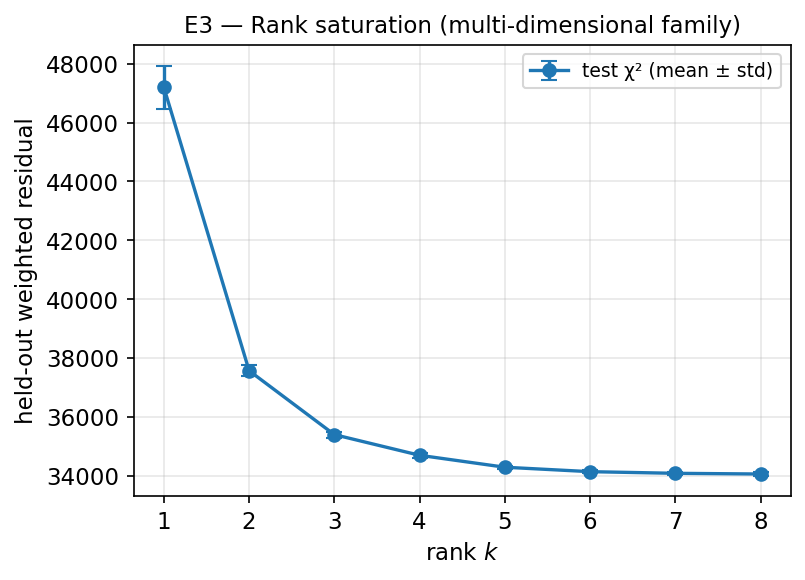

Δχ²(1→2) / χ²(1) = 0.2040


In [9]:
e3_by_seed = {}
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e3_e9'):
        path = f'e3_e9/{sg}/rank_summary'
        if path not in h5:
            continue
        df = load_df(h5, path)
        e3_by_seed[sg] = df

if not e3_by_seed and _fallback:
    df = _fallback['b06']['rank_summary_df'][['k', 'chi2_proxy_mean', 'chi2_proxy_std']].copy()
    e3_by_seed['fallback'] = df

ks_common = sorted(list(e3_by_seed.values())[0]['k'].astype(int))
chi2_stack = np.stack(
    [df.sort_values('k')['chi2_proxy_mean'].values for df in e3_by_seed.values()], axis=0)
mu_chi2, sd_chi2 = mean_std(chi2_stack)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.errorbar(ks_common, mu_chi2, yerr=sd_chi2, fmt='o-', color=BLUE,
            capsize=4, label='test χ² (mean ± std)')
ax.set_xlabel('rank $k$')
ax.set_ylabel('held-out weighted residual')
ax.set_title('E3 — Rank saturation (multi-dimensional family)')
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, 'e3_rank_saturation.pdf')
plt.show()

drop_12 = (mu_chi2[0] - mu_chi2[1]) / mu_chi2[0]
print(f'Δχ²(1→2) / χ²(1) = {drop_12:.4f}')


---
## E6 — Noise-aware EMPCA vs isotropic PCA ablation

*Paper §7 main result.  
Relative improvement = (χ²_iso − χ²_weighted) / χ²_iso.  
White noise → ~0; pink/brownian → significant gap.*


  saved → results/figures/e6_ablation.pdf


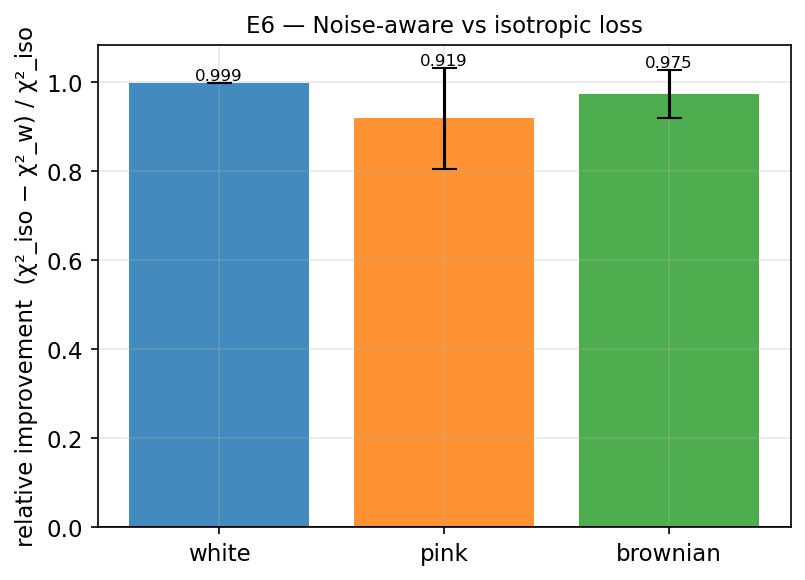

,noise_type,mean,std
0,white,0.999383,0.000264
1,pink,0.919481,0.113148
2,brownian,0.974589,0.053881


In [10]:
e6_by_seed = {}
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e6_e7'):
        path = f'e6_e7/{sg}/e6'
        if path not in h5:
            continue
        df = load_df(h5, path)
        e6_by_seed[sg] = df

if not e6_by_seed and _fallback:
    e6_by_seed['fallback'] = _fallback['b07']['ablation_df'].copy()

noise_types = list(e6_by_seed.values())[0]['noise_type'].tolist()
ri_stack = np.stack(
    [df.set_index('noise_type').loc[noise_types, 'relative_improvement'].values
     for df in e6_by_seed.values()], axis=0)
mu_ri, sd_ri = mean_std(ri_stack)

fig, ax = plt.subplots(figsize=(5.5, 4))
x = np.arange(len(noise_types))
ax.bar(x, mu_ri, yerr=sd_ri, capsize=6, color=[BLUE, ORANGE, GREEN][:len(noise_types)],
       alpha=0.85, error_kw={'ecolor': 'black', 'lw': 1.5})
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(noise_types)
ax.set_ylabel('relative improvement  (χ²_iso − χ²_w) / χ²_iso')
ax.set_title('E6 — Noise-aware vs isotropic loss')
for xi, (m, s) in enumerate(zip(mu_ri, sd_ri)):
    ax.text(xi, m + s + 0.005, f'{m:.3f}', ha='center', fontsize=8)
fig.tight_layout()
save_fig(fig, 'e6_ablation.pdf')
plt.show()

e6_summary = pd.DataFrame({'noise_type': noise_types, 'mean': mu_ri, 'std': sd_ri})
display(e6_summary)


---
## E7 — Template mismatch: fixed-template OF vs EMPCA

*Paper §3.4.  
**Fix vs original block_07:** x-axis is τ_decay (ms), not cos²(θ_w).  
This shows that OF bias grows as the pulse decays faster or slower than nominal.*


  saved → results/figures/e7_mismatch_curve.pdf


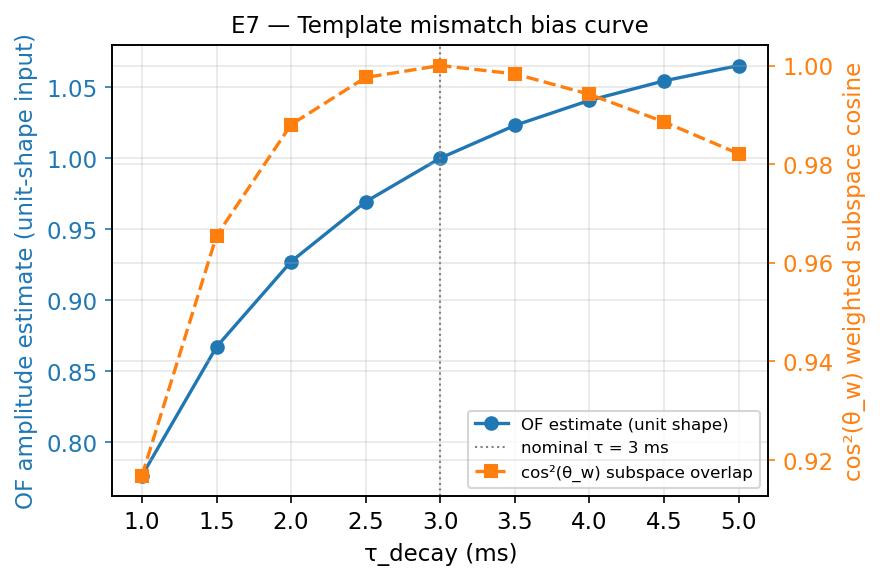

In [11]:
e7_curve_by_seed = {}
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e6_e7'):
        path = f'e6_e7/{sg}/e7/curve'
        if path not in h5:
            continue
        df = load_df(h5, path)
        e7_curve_by_seed[sg] = df

if not e7_curve_by_seed and _fallback:
    e7_curve_by_seed['fallback'] = _fallback['b07']['mismatch_curve_df'].copy()

# The curve is deterministic (no noise) — average just for robustness
ref = list(e7_curve_by_seed.values())[0].sort_values('tau_decay')
tau_ms = ref['tau_decay'].values / 1e6   # ns → ms
cos2  = ref['cosine_squared'].values
of_est= ref['of_estimate_for_unit_shape'].values

fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

ax1.plot(tau_ms, of_est, 'o-', color=BLUE, label='OF estimate (unit shape)')
ax2.plot(tau_ms, cos2,   's--', color=ORANGE, label='cos²(θ_w) subspace overlap')

ax1.axvline(3.0, color='gray', ls=':', lw=1, label='nominal τ = 3 ms')
ax1.set_xlabel('τ_decay (ms)')
ax1.set_ylabel('OF amplitude estimate (unit-shape input)', color=BLUE)
ax2.set_ylabel('cos²(θ_w) weighted subspace cosine', color=ORANGE)
ax1.tick_params(axis='y', colors=BLUE)
ax2.tick_params(axis='y', colors=ORANGE)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')
ax1.set_title('E7 — Template mismatch bias curve')
fig.tight_layout()
save_fig(fig, 'e7_mismatch_curve.pdf')
plt.show()


In [12]:
# E7 summary table: OF vs EMPCA k=1 vs k=2 amplitude error
e7_rows = []
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e6_e7'):
        path = f'e6_e7/{sg}/e7'
        if path not in h5:
            continue
        df = load_df(h5, path)
        df['seed'] = sg
        e7_rows.append(df)

if e7_rows:
    e7_all = pd.concat(e7_rows, ignore_index=True)
elif _fallback:
    e7_all = _fallback['b07']['mismatch_df'].copy()
    e7_all['seed'] = 'fallback'
else:
    e7_all = pd.DataFrame()

if not e7_all.empty:
    e7_agg = e7_all.groupby('method')[['mean_relative_bias', 'rmse']].agg(['mean', 'std'])
    display(e7_agg)


TypeError: Accessing a group is done with bytes or str, not <class 'tuple'>

---
## E9 — EMPCA convergence traces

*Paper §6.1.  
χ² should decrease monotonically; convergence within ~50 iterations.*


In [ ]:
e9_dfs = []
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e3_e9'):
        path = f'e3_e9/{sg}/e9'
        if path not in h5:
            continue
        df = load_df(h5, path)
        df['seed'] = sg
        e9_dfs.append(df)

if not e9_dfs and _fallback:
    df = _fallback['b06']['convergence_df'].copy()
    df['seed'] = 'fallback'
    e9_dfs = [df]

e9_all = pd.concat(e9_dfs, ignore_index=True)

# Normalise per (seed, k, init) so all start at 1.0 for comparison
def normalize_chi2(df):
    df = df.copy()
    groups = df.groupby(['seed', 'k', 'init'])['chi2']
    chi2_0 = groups.transform('first')
    df['chi2_norm'] = df['chi2'] / chi2_0.replace(0, np.nan)
    return df

e9_all = normalize_chi2(e9_all)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
colors = {1: BLUE, 2: ORANGE, 3: GREEN}
for ax, init in zip(axes, ['random', 'svd']):
    sub = e9_all[e9_all['init'] == init]
    for k, grp in sub.groupby('k'):
        if k not in (1, 2, 3):
            continue
        # mean / std across seeds per iteration
        it_grp = grp.groupby('iteration')['chi2_norm']
        mu = it_grp.mean()
        sd = it_grp.std()
        iters = mu.index.values
        ax.plot(iters, mu.values, color=colors[k], label=f'k={k}')
        ax.fill_between(iters, mu - sd, mu + sd, color=colors[k], alpha=0.15)
    ax.set_xlabel('iteration')
    ax.set_ylabel('normalised χ² surrogate')
    ax.set_title(f'init = {init}')
    ax.legend(fontsize=9)

fig.suptitle('E9 — EMPCA convergence (shading = std across seeds)', fontsize=11)
fig.tight_layout()
save_fig(fig, 'e9_convergence.pdf')
plt.show()


In [ ]:
# Convergence summary table
e9_summary_dfs = []
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e3_e9'):
        path = f'e3_e9/{sg}/e9/summary'
        if path not in h5:
            continue
        df = load_df(h5, path)
        df['seed'] = sg
        e9_summary_dfs.append(df)

if e9_summary_dfs:
    e9_smry = pd.concat(e9_summary_dfs, ignore_index=True)
    display(e9_smry.groupby(['k', 'init'])[['iterations_used', 'iter_to_relative_tol_1e-6', 'monotone_nonincreasing']]
            .agg(lambda x: f'{x.mean():.1f} ± {x.std():.1f}' if x.dtype != bool else x.all()))
elif _fallback:
    display(_fallback['b06']['convergence_summary_df'])


---
## E8 — Time-shift OF vs fixed-template OF

*Paper §3.2.  
Time-shift OF should recover arrival time with lower RMSE than fixed OF.*


In [ ]:
e8_rows = []
with h5py.File(CACHE_H5, 'r') as h5:
    for sg in cache_groups(h5, 'e6_e7'):
        path = f'e6_e7/{sg}/e8'
        if path not in h5:
            continue
        df = load_df(h5, path)
        df['seed'] = sg
        e8_rows.append(df)

if e8_rows:
    e8_all = pd.concat(e8_rows, ignore_index=True)
elif _fallback:
    e8_all = _fallback['b07']['shift_df'].copy()
    e8_all['seed'] = 'fallback'
else:
    e8_all = pd.DataFrame()

if not e8_all.empty:
    display(e8_all.groupby('method')[['amplitude_rmse', 'mean_relative_bias']].agg(['mean', 'std']))


---
## Summary — figures saved to `results/figures/`

| File | Experiment | Section |
|---|---|---|
| `e2_bridge_cosines.pdf` | E2: Bridge Theorem cosines | §5.3 |
| `e3_rank_saturation.pdf` | E3: χ²(k) monotone | §4.4 |
| `e4_crb_verification.pdf` | E4: CRB | §3.2 |
| `e5_resolution_scaling.pdf` | E5: σ_E scaling (error bars) | §3.2 |
| `e6_ablation.pdf` | E6: noise-aware vs iso (error bars) | §7 |
| `e7_mismatch_curve.pdf` | E7: template mismatch | §3.4 |
| `e9_convergence.pdf` | E9: convergence (shaded band) | §6.1 |


In [ ]:
print('All figures saved to:', FIG_DIR)
for f in sorted(FIG_DIR.glob('*.pdf')):
    print(' ', f.name)
